Today's topics:
* correlation and the Pearson `r`
* fitting a line with `scipy.stats.linregress`
* interpreting slope, intercept, and predictions

# Correlated material properties

Consider the destructive tensile testing of Ti alloys.
We can obtain two different stresses from each tensile test.
Yield strength (YS) is the stress where it starts to deform permanently.
Ultimate tensile strength (UTS) is the highest stress it reaches during the test.

<img src="https://upload.wikimedia.org/wikipedia/commons/6/6f/Al_tensile_test.jpg" alt="An aluminum alloy tensile specimen broken in two, with visible necking near the break and a cup and cone fracture surface" width=520/>

*Photo by Sigmund, [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/), [via Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Al_tensile_test.jpg).*

Above: A tensile specimen taken to fracture.
The "necking" near the break is permanent deformation.

The two schematic curves above show the relation between YS and UTS.
An alloy with higher YS *typically* also reaches higher UTS.
Is it always true?

# The titanium alloy dataset

We used these titanium alloy dataset before: [Salvador et al., *Scientific Data* 9, 188](https://doi.org/10.1038/s41597-022-01283-9) (CC BY 4.0.)

In [1]:
import pandas as pd

data = pd.read_csv('https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/biomaterials_ti_alloys.csv')

In [2]:
display(data.head())
print(data.shape)

,eid,Al_frac,Cr_frac,Cu_frac,Fe_frac,Hf_frac,Mn_frac,Mo_frac,Nb_frac,Ni_frac,...,DAR_pct,DAR_err,test_mode,HV,HV_err,Mo_equivalent,Mo_equivalent_class,ref_doi,ref_key,comments
0,Ti-23Nb-10Zr-2.0Fe,0.0,0.0,0.0,0.023400,0.0,0.0,0.0,0.135800,0.0,...,10.0,1.0,tension,252.0,8.0,12.88,meta,10.1007/s10853-021-06002-0,salvador2021,Young modulus obtained via tensile tests (Tabl...
1,Ti-27Nb-10Zr-1.5Fe,0.0,0.0,0.0,0.015600,0.0,0.0,0.0,0.163200,0.0,...,9.0,1.0,tension,229.0,2.0,11.65,meta,10.1007/s10853-021-06002-0,salvador2021,Young modulus obtained via tensile tests (Tabl...
2,Ti-31Nb-10Zr-1.0Fe,0.0,0.0,0.0,0.013801,0.0,0.0,0.0,0.189919,0.0,...,15.0,6.0,tension,218.0,5.0,12.08,meta,10.1007/s10853-021-06002-0,salvador2021,Young modulus obtained via tensile tests (Tabl...
3,Ti-11Nb-7Zr-3.5Fe,0.0,0.0,0.0,0.034903,0.0,0.0,0.0,0.061806,0.0,...,4.0,1.0,tension,358.0,3.0,13.78,meta,10.1016/j.matdes.2018.10.040,dalbo2018,Young modulus obtained via tensile tests (Tabl...
4,Ti-19Nb-6Sn-2.5Fe,0.0,0.0,0.0,0.025600,0.0,0.0,0.0,0.110000,0.0,...,31.0,5.0,tension,260.0,9.0,12.76,meta,10.1016/j.matdes.2018.10.040,dalbo2018,Young modulus obtained via tensile tests (Tabl...


(283, 43)


# Correlation: `stats.pearsonr`

## Seeing the pair first

Start with the figure before reducing the relationship to one number.

Text(0, 0.5, 'ultimate tensile strength (MPa)')

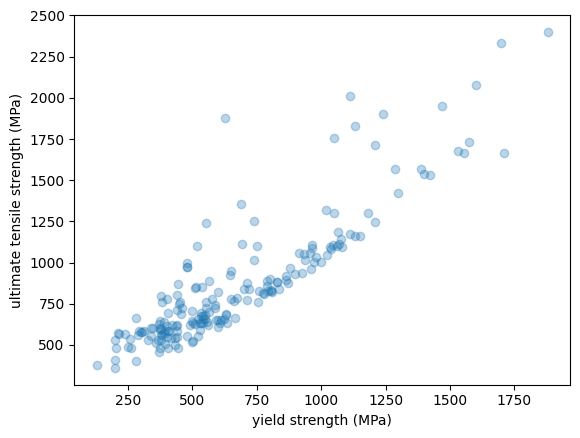

In [3]:
import matplotlib.pyplot as plt

x = data['YS_MPa']
y = data['UTS_MPa']

fig, ax = plt.subplots()
ax.scatter(x, y, alpha=0.3)  # alpha makes the overlapping points readable
ax.set_xlabel('yield strength (MPa)')
ax.set_ylabel('ultimate tensile strength (MPa)')

The cloud rises to the right, so alloys with a high yield strength tend to have a high tensile strength.
The points sit in a band rather than on a line, which is what we would expect from a hundred different studies.
Not always: alloys with similar yield strengths can differ widely in tensile strength.

"Rises to the right" is a description, not a measurement.
The **Pearson correlation coefficient**, written `r`, puts one number on how close a cloud of points comes to a straight line.

SciPy computes it with `stats.pearsonr`.
Try it on `YS_MPa` and `UTS_MPa`.

In [4]:
from scipy import stats

print(f"r = {stats.pearsonr(x, y).statistic:.3f}")

r = nan


The result is `nan`, with no error or warning.

You saw this at L08: `np.mean` returned `nan` when an array contained a missing value.

We used `np.nanmean` to average only the recorded values.

A correlation uses yield strength and tensile strength from the same alloy as one pair.
Skipping missing entries in each column separately could pair measurements from different alloys.
`stats.pearsonr` does not skip incomplete pairs, so we first keep only rows with both measurements.

## Rows with both measurements: `.dropna`

In `.dropna(subset=['YS_MPa', 'UTS_MPa'])`, `subset` names the two columns we need.
`.dropna` keeps a row if both measurements are present, even when another property is missing.

In [5]:
both = data.dropna(subset=['YS_MPa', 'UTS_MPa'])
print(f'{len(both)} of {len(data)} alloys report both properties')

x = both['YS_MPa']
y = both['UTS_MPa']

190 of 283 alloys report both properties


L08's rule still applies: dropping missing values changes the question being answered, so report how many rows are left.
Of the 283 alloys, 190 have both measurements, so the correlation describes those 190.

The scatter above also used only these 190 complete pairs because `ax.scatter` omits rows with a missing value in either plotted column.

## Building `r` from deviations

What does `stats.pearsonr` compute?
We can build that number out of something we already have.

In L05 we subtracted the mean from a column to get its deviations, squared them, and summed the squares to get the variance.
Here we have two columns, so we take the deviations of both.

In [6]:
import numpy as np

dx = x - np.mean(x)  # each alloy's yield strength, relative to the mean
dy = y - np.mean(y)  # each alloy's tensile strength, relative to the mean

print(dx.head())

12   -326.595789
13    -68.595789
14    -49.595789
15    -45.595789
20   -137.595789
Name: YS_MPa, dtype: float64


Now multiply the two deviations together, alloy by alloy.

An alloy above the mean in both columns gives a positive product, and so does an alloy below the mean in both.
An alloy above the mean in one column and below it in the other gives a negative product.

So the sum of those products is large and positive when the two columns move together, and large and negative when they move against each other.

In [7]:
products = dx * dy
print(f'sum of products = {np.sum(products):.0f}')

sum of products = 22212126


That sum grows with the size of the measurements and with the number of alloys, so on its own it compares nothing.
Dividing by the two sums of squared deviations removes both, and what is left is the Pearson `r`:

$$r = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_i (x_i - \bar{x})^2}\ \sqrt{\sum_i (y_i - \bar{y})^2}}$$

In [8]:
r_by_hand = np.sum(products) / np.sqrt(np.sum(dx ** 2) * np.sum(dy ** 2))
print(f'r (by hand) = {r_by_hand:.3f}')

r (by hand) = 0.882


The denominator is what holds the answer between -1 and +1, whatever units the two columns are in.

## `stats.pearsonr`

SciPy does that arithmetic in one line.

In [9]:
correlation = stats.pearsonr(x, y)
print(f'r = {correlation.statistic:.3f}')

r = 0.882


## Direction and strength

`r` runs from -1 to +1, and it reports two separate things at once.

The **sign** is the direction: positive means the cloud rises to the right, negative means it falls to the right.
The **distance from zero** is the strength: at 1 or -1 every point sits on the line, and near 0 there is no straight-line pattern to measure.

The two are independent, so changing one of them leaves the other alone.

A value near zero rules out a straight-line pattern and nothing else, so a curved relationship can sit at an `r` of almost zero.

0.882 is a strong positive relationship, and the width of the band is why it is not closer to 1.

## What other values of `r` look like

The only correlation we have measured so far is 0.882, which is a strong one.
Here are four more pairs from the same compilation.

`HV` is the Vickers hardness, measured by pressing a diamond into the surface and measuring the dent.
`YM_GPa` is Young's modulus, the stiffness of the alloy in the elastic region before it yields.
`DAR_pct` is the deformation at rupture, how far a specimen stretched before it broke.

In [10]:
hardness = data.dropna(subset=['YS_MPa', 'HV'])
stiffness = data.dropna(subset=['YM_GPa', 'YS_MPa'])
ductility = data.dropna(subset=['Ti_frac', 'DAR_pct'])
composition = data.dropna(subset=['Al_frac', 'Ti_frac'])

print(f"YS and HV:        r = {stats.pearsonr(hardness['YS_MPa'], hardness['HV']).statistic:.3f}")
print(f"YM and YS:        r = {stats.pearsonr(stiffness['YM_GPa'], stiffness['YS_MPa']).statistic:.3f}")
print(f"Ti and DAR:       r = {stats.pearsonr(ductility['Ti_frac'], ductility['DAR_pct']).statistic:.3f}")
print(f"Al and Ti:        r = {stats.pearsonr(composition['Al_frac'], composition['Ti_frac']).statistic:.3f}")

YS and HV:        r = 0.875
YM and YS:        r = 0.511
Ti and DAR:       r = -0.014
Al and Ti:        r = -0.300


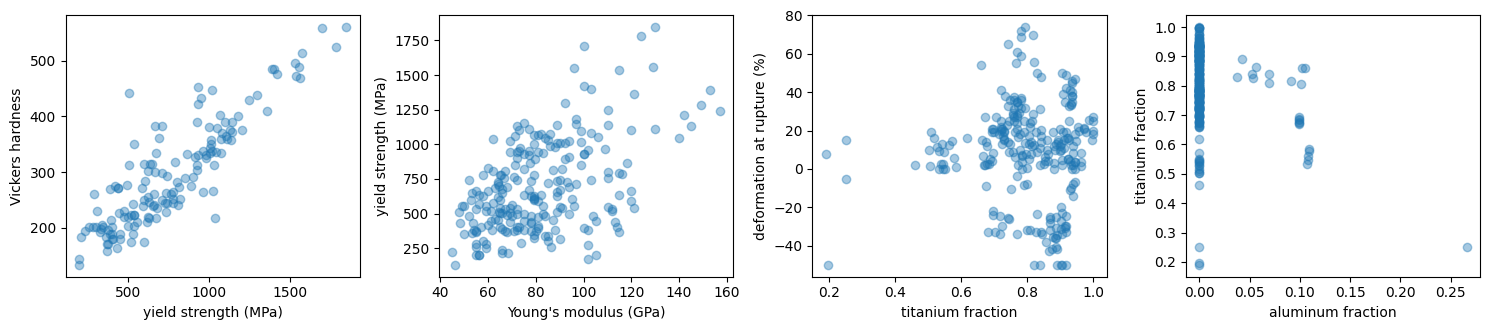

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))

axes[0].scatter(hardness['YS_MPa'], hardness['HV'], alpha=0.4)
axes[0].set_xlabel('yield strength (MPa)')
axes[0].set_ylabel('Vickers hardness')

axes[1].scatter(stiffness['YM_GPa'], stiffness['YS_MPa'], alpha=0.4)
axes[1].set_xlabel("Young's modulus (GPa)")
axes[1].set_ylabel('yield strength (MPa)')

axes[2].scatter(ductility['Ti_frac'], ductility['DAR_pct'], alpha=0.4)
axes[2].set_xlabel('titanium fraction')
axes[2].set_ylabel('deformation at rupture (%)')

axes[3].scatter(composition['Al_frac'], composition['Ti_frac'], alpha=0.4)
axes[3].set_xlabel('aluminum fraction')
axes[3].set_ylabel('titanium fraction')

fig.tight_layout()

The first panel is nearly as tight as our yield-strength scatter, and hardness is measured by resisting a small permanent dent, much as yield strength is the stress that causes a permanent bend.

The second is the same sign and half the size, and the band is visibly wider.
Stiffness comes mostly from the bonding, while yield strength depends on the microstructure, so the two are related without being tied together.

The third panel shows what an `r` near zero looks like: a cloud with no tilt to it.
There is no linear trend in those points to measure.

The fourth is negative, and the cloud falls to the right.
Because elemental fractions sum to one, increasing the aluminum fraction can reduce the titanium fraction even without a broader metallurgical relationship.

A negative `r` on a composition pair like that one is a constraint of how the alloy was mixed, not a discovery about how metals behave.

## What `r` does not say

A large `r` says the two columns move together, not that one causes the other.

Chemistry, processing and microstructure can affect both properties, so a third factor can move them together.

An `r` this size is a reason to go looking for a mechanism rather than a substitute for finding one.

### [Check your understanding]

`DAR_pct` is the deformation at rupture, how far a specimen stretched before it broke, as a percentage.

1. Build a table called `ductile` holding the rows where `YS_MPa` and `DAR_pct` are both reported, using `.dropna` with those two column names.
2. Print how many alloys that leaves.
3. Make a `fig, ax` scatter of `DAR_pct` against `YS_MPa`.
4. Label both axes.
5. Compute the Pearson `r` with `stats.pearsonr`, then print the result's `.statistic` field.
6. In a comment, give the sign and the size of that `r`, and what the sign means for someone choosing an alloy.

*That number supports no claim about which way any causation runs, or whether there is any.*

# What a model is

Given an alloy's yield strength, what is its ultimate tensile strength likely to be?

Everything after this point produces a **model**, so it is worth saying what one is before we build it.

A model is a simplified representation of something, kept because we can use it to answer a practical question.
It is not a claim to be an exact description: the test of a model is whether it is useful, not whether it is right about every case.

A line through these 190 alloys is a model of the average relationship between the two strengths.
Individual alloys are not required to sit on it.

A straight line is a common first model because two numbers, a slope and an intercept, describe the whole thing, and both can be read in the units of the data.

# Fitting a line: `stats.linregress`

`r` describes how closely the points follow a line, but not the line's slope or intercept.
`stats.linregress` fits `y = m*x + b` by least squares and returns an object with named fields.
Least squares returns the line with the smallest total squared vertical gaps from the data.

In [12]:
fit = stats.linregress(x, y)

print(f'slope     = {fit.slope:.3f}')
print(f'intercept = {fit.intercept:.1f} MPa')
print(f'r         = {fit.rvalue:.3f}')

slope     = 0.985
intercept = 204.3 MPa
r         = 0.882


`fit.rvalue` is the same 0.882 stored in `correlation.statistic`.
The fit contains it because the correlation and the line are two answers to one question about these columns.

## Reading the fitted equation

The fitted line is `UTS = 0.985 * YS + 204`.
Because both axes use MPa, the slope means 0.985 MPa of predicted tensile strength per 1 MPa of yield strength.

The intercept is the model's predicted tensile strength at zero yield strength, which lies outside the measured range and has no direct implant interpretation.

# Prediction, inside and outside the data

Substituting a yield strength into the fitted equation gives a predicted tensile strength.

In [13]:
pred_800 = fit.slope * 800 + fit.intercept
print(f'800 MPa yield strength predicts {pred_800:.0f} MPa tensile strength')

800 MPa yield strength predicts 992 MPa tensile strength


The alloys this line was fit on run from 130 to 1880 MPa of yield strength, so 800 sits well inside them.
A prediction inside the fitted range is **interpolation**, and the surrounding data is what supports it.

In [14]:
print(f'{np.min(x):.0f} to {np.max(x):.0f} MPa of yield strength in the fitted alloys')

pred_2500 = fit.slope * 2500 + fit.intercept
print(f'2500 MPa yield strength predicts {pred_2500:.0f} MPa tensile strength')

130 to 1880 MPa of yield strength in the fitted alloys
2500 MPa yield strength predicts 2666 MPa tensile strength


2500 MPa is beyond every alloy in the table, which makes that second number **extrapolation**.

Python returned a value because the calculation applies the equation without checking the fitted range.
This compilation does not support extending the same slope that far.

# Summary

* The Pearson `r` measures how close two columns come to a straight line, from -1 to +1.
* `r` is built from the deviations of both columns: the sum of their products, divided by the two sums of squares.
* The sign of `r` is the direction and its distance from zero is the strength, and the two are independent.
* A large `r` does not establish that one property causes the other.
* `stats.linregress` returns the fitted line as `slope`, `intercept` and `rvalue`.
* A slope has units of y per x; an intercept has the units of y and describes the model at x equal to zero.
* Interpolation predicts inside the fitted range, and extrapolation runs the same arithmetic where no data supports it.

Across 190 titanium-alloy records, tensile strength rises about 0.985 MPa for each additional MPa of yield strength.
At 800 MPa yield strength, the line predicts a tensile strength near 992 MPa.

# Before Quiz 4

Quiz 4 covers Lectures 9, 10 and 11, not today's regression.

It uses three of the question formats Midterm 1 will use.

In the first question you read printed output, say what each number means, and caption one of them by naming the population it describes.
In the second you read a marked line of code and write one sentence on what that line does and why it is there for this data, the way the inline comments in these notebooks do.

Then you judge a plotting choice and say why it is the wrong one.

You do not need to write code from scratch, on the quiz or on the exam.

## Further reading

- Salvador, C. A. F. et al. "A compilation of experimental data on the mechanical properties and microstructural features of Ti-alloys." *Scientific Data* 9, 188 (2022). https://doi.org/10.1038/s41597-022-01283-9
- [SciPy documentation: `scipy.stats.pearsonr`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html)
- [SciPy documentation: `scipy.stats.linregress`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html)

# Appendix: the rest of the `linregress` result

`fit` contains more than the three fields we read today.

In [15]:
print(fit)

LinregressResult(slope=np.float64(0.9845743208599055), intercept=np.float64(204.2655718818903), rvalue=np.float64(0.8821839049417173), pvalue=np.float64(2.1357158193744694e-63), stderr=np.float64(0.03833043868335523), intercept_stderr=np.float64(29.035579557337773))


Today we used `fit.slope`, `fit.intercept`, and `fit.rvalue`.
The remaining fields belong to statistics we have not covered, and we will leave them alone until we have.

Reading a field by name is what makes that possible: `fit.slope` selects which number we retrieve, so we can leave the fields we have not met unused.